# 6CS012 - Artificial Intelligence and Machine Learning
## Tutorial 7: Representation Learning and Autoencoder


In [1]:
# Install / verify libraries
!pip install tensorflow numpy matplotlib pillow scikit-learn -q
print("Libraries ready.")

Libraries ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request, zipfile, glob

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from PIL import Image

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


---
## Part 1 — MNIST Denoising Autoencoder (Tutorial Walkthrough)
---

### Step 1 — Load, Preprocess & Add Noise to MNIST

In [3]:
# ── Load MNIST ────────────────────────────────────────────────────────────────
(x_train, _), (x_test, _) = mnist.load_data()

# ── Normalise to [0, 1] ───────────────────────────────────────────────────────
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32')  / 255.

# ── Reshape to (N, 28, 28, 1) — add channel dimension ────────────────────────
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

print(f"x_train shape : {x_train.shape}")
print(f"x_test  shape : {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape : (60000, 28, 28, 1)
x_test  shape : (10000, 28, 28, 1)


In [4]:
# ── Add Gaussian noise at two levels ─────────────────────────────────────────
noise_factor_low  = 0.1
noise_factor_high = 0.5

x_train_noisy_low  = x_train + noise_factor_low  * np.random.normal(0., 1., x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(0., 1., x_train.shape)
x_test_noisy_low   = x_test  + noise_factor_low  * np.random.normal(0., 1., x_test.shape)
x_test_noisy_high  = x_test  + noise_factor_high * np.random.normal(0., 1., x_test.shape)

# ── Clip to [0, 1] ────────────────────────────────────────────────────────────
x_train_noisy_low  = np.clip(x_train_noisy_low,  0., 1.)
x_test_noisy_low   = np.clip(x_test_noisy_low,   0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high  = np.clip(x_test_noisy_high,  0., 1.)

# ── We will train with the HIGH noise version ─────────────────────────────────
x_test_noisy = x_test_noisy_high

print("Noisy datasets prepared.")

Noisy datasets prepared.


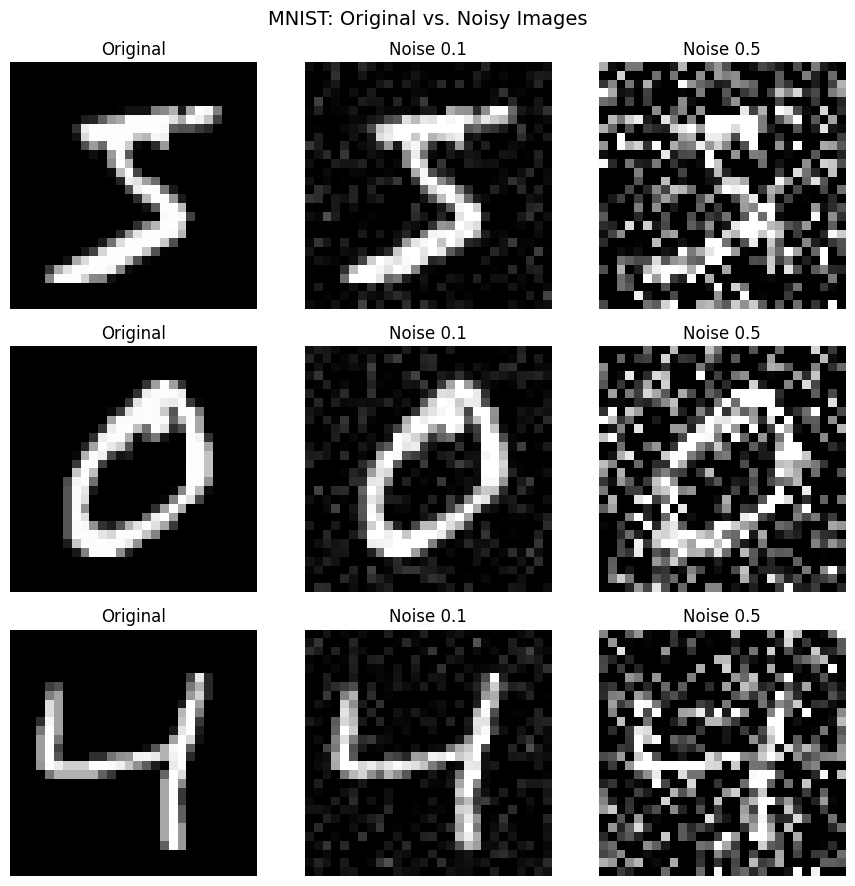

In [5]:
# ── Visualise: Original | Noise 0.1 | Noise 0.5  (3 × 3 grid) ────────────────
n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original");  plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1"); plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5"); plt.axis('off')

plt.suptitle("MNIST: Original vs. Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

### Step 2 — Build the Convolutional Denoising Autoencoder

In [6]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.

    Architecture:
        Input (28×28×1)
        → Conv2D(32, 3×3, ReLU, same)  → (28×28×32)
        → MaxPooling2D(2×2)            → (14×14×32)
        → Conv2D(64, 3×3, ReLU, same)  → (14×14×64)
        → MaxPooling2D(2×2)  [encoded] → (7×7×64)

    Returns:
        input_img : Keras Input tensor
        encoded   : Latent representation tensor
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [7]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.

    Architecture (mirrors the encoder):
        Encoded (7×7×64)
        → Conv2D(64, 3×3, ReLU, same)  → (7×7×64)
        → UpSampling2D(2×2)            → (14×14×64)
        → Conv2D(32, 3×3, ReLU, same)  → (14×14×32)
        → UpSampling2D(2×2)            → (28×28×32)
        → Conv2D(1,  3×3, Sigmoid)     → (28×28×1)  ← reconstructed image

    Returns:
        decoded : Reconstructed output tensor
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [8]:
def build_autoencoder(input_shape=(28, 28, 1)):
    """
    Constructs and compiles the full convolutional autoencoder.

    Loss    : binary_crossentropy  (pixel values in [0,1])
    Optimiser: Adam

    Returns:
        autoencoder : Compiled Keras Model
    """
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# ── Build and print summary ───────────────────────────────────────────────────
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3 — Train the Autoencoder

In [9]:
# ── Train: noisy images → clean images ────────────────────────────────────────
history = autoencoder.fit(
    x_train_noisy_high, x_train,        # INPUT: noisy  |  TARGET: clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.1493 - val_loss: 0.1111
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1086 - val_loss: 0.1056
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1041 - val_loss: 0.1021
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1017 - val_loss: 0.1007
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1002 - val_loss: 0.0992
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0990 - val_loss: 0.0980
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0980 - val_loss: 0.0970
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0973 - val_loss: 0.0962
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0967 - val_loss: 0.0957
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0961 - val_loss: 0.0953


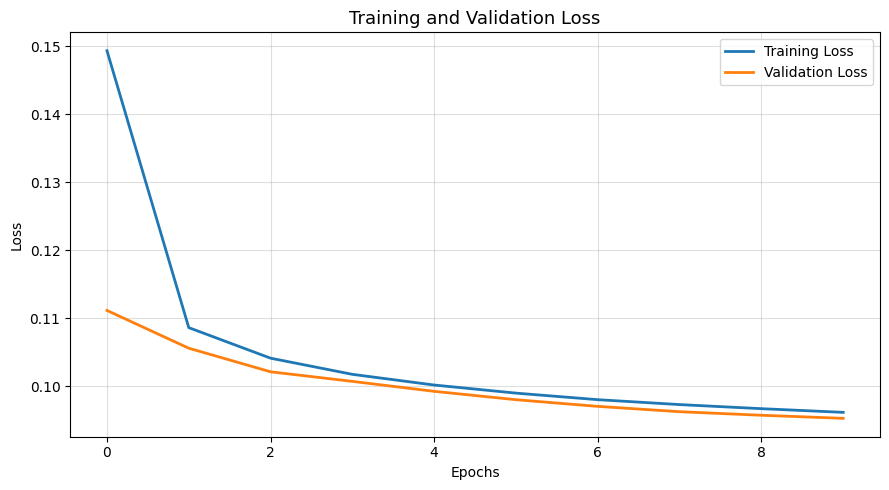

In [10]:
# ── Plot Training & Validation Loss ──────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Step 4 — Evaluate the Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Denoised images shape: (10000, 28, 28, 1)


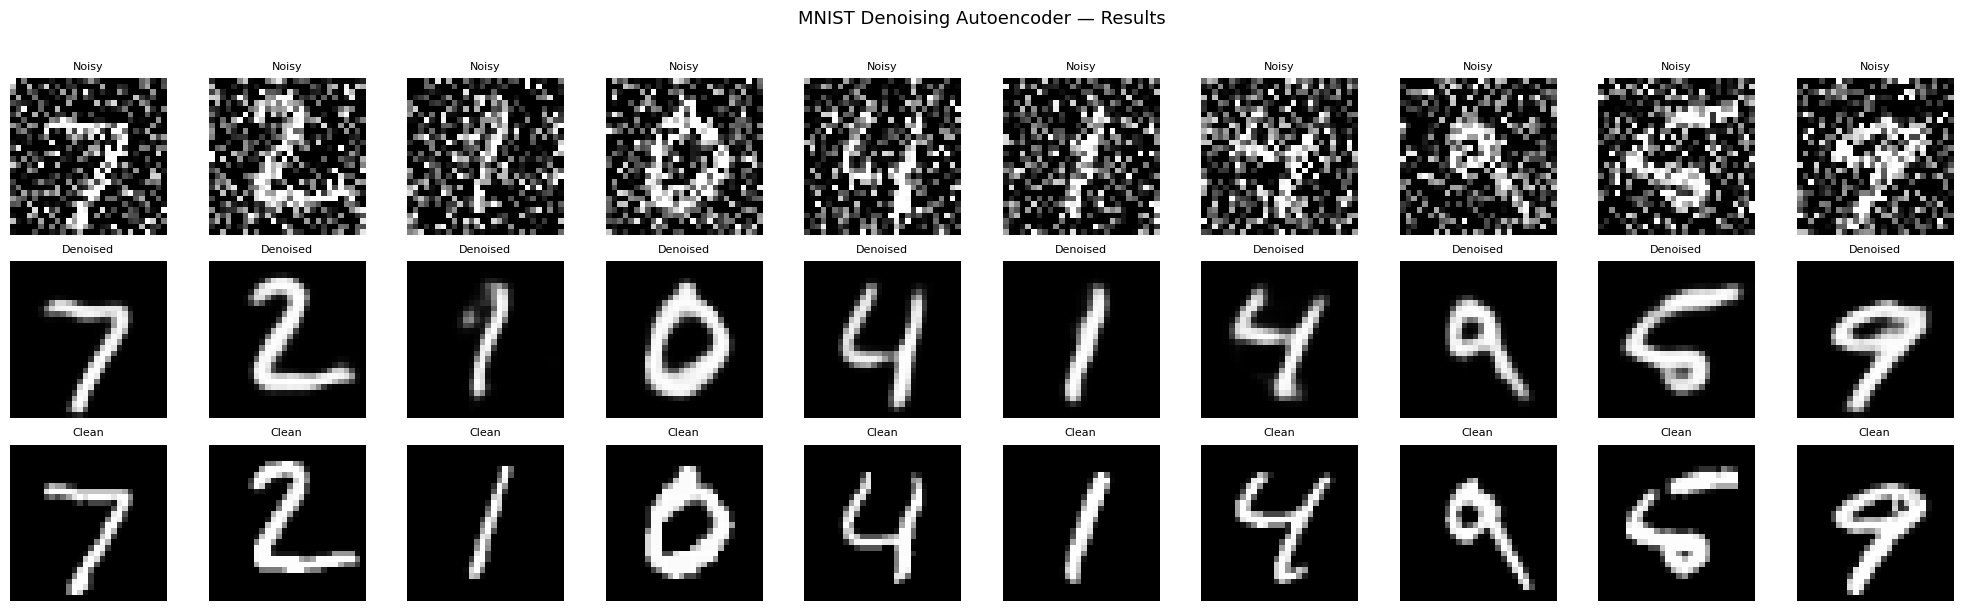

In [11]:
# ── Predict denoised images ───────────────────────────────────────────────────
denoised_images = autoencoder.predict(x_test_noisy)
print(f"Denoised images shape: {denoised_images.shape}")

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    """
    Displays n images in a 3-row grid:
        Row 1 — Noisy input
        Row 2 — Autoencoder reconstructed (denoised)
        Row 3 — Original clean image
    """
    plt.figure(figsize=(20, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy", fontsize=8); plt.axis('off')

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised", fontsize=8); plt.axis('off')

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean", fontsize=8); plt.axis('off')

    plt.suptitle("MNIST Denoising Autoencoder — Results", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy, denoised_images, x_test, n=10)

---
## Part 2 — Exercise: Denoising Autoencoder on Devanagari Handwritten Digit Dataset
---

We now build a **deeper** (≥ 4 encoder layers) denoising convolutional autoencoder on the
Devanagari Handwritten Character dataset.

### Step 1 — Download & Prepare the Devanagari Dataset

In [14]:
# ── Use provided Devanagari Handwritten Character Dataset ──────────────────────
# The user has provided a local path to the dataset.

# Set DATA_DIR to the parent directory that contains both 'Train' and 'Test' subfolders
DATA_DIR  = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/DevanagariHandwrittenDigitDataset"

if not os.path.exists(DATA_DIR):
    print(f"Error: The provided dataset path '{DATA_DIR}' does not exist. Please ensure Google Drive is mounted and the path is correct.")
else:
    print(f"Using dataset from: {DATA_DIR}")

# Find image paths
# The glob pattern recursively searches for all .png files within the provided directory structure.
img_paths = glob.glob(os.path.join(DATA_DIR, '**', '*.png'), recursive=True)
print(f"Total images found: {len(img_paths)}")

Using dataset from: /content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/DevanagariHandwrittenDigitDataset
Total images found: 20000


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# ── Load images → NumPy array ─────────────────────────────────────────────────
IMG_SIZE = 32   # Resize to 32×32 for cleaner architecture
MAX_IMGS = 10000  # Cap at 10 000 for reasonable Colab training time

images = []
for path in img_paths[:MAX_IMGS]:
    try:
        img = Image.open(path).convert('L')            # Grayscale
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        images.append(np.array(img, dtype='float32'))
    except Exception:
        continue

X_dev = np.array(images)                              # (N, 32, 32)
X_dev = X_dev / 255.0                                 # Normalise to [0, 1]
X_dev = X_dev[..., np.newaxis]                        # (N, 32, 32, 1)

print(f"Devanagari dataset shape: {X_dev.shape}")
print(f"Pixel range: [{X_dev.min():.2f}, {X_dev.max():.2f}]")

Devanagari dataset shape: (10000, 32, 32, 1)
Pixel range: [0.00, 1.00]


In [17]:
# ── Train / Validation split ─────────────────────────────────────────────────
X_dev_train, X_dev_val = train_test_split(X_dev, test_size=0.15, random_state=42)
print(f"Train : {X_dev_train.shape}  |  Val : {X_dev_val.shape}")

Train : (8500, 32, 32, 1)  |  Val : (1500, 32, 32, 1)


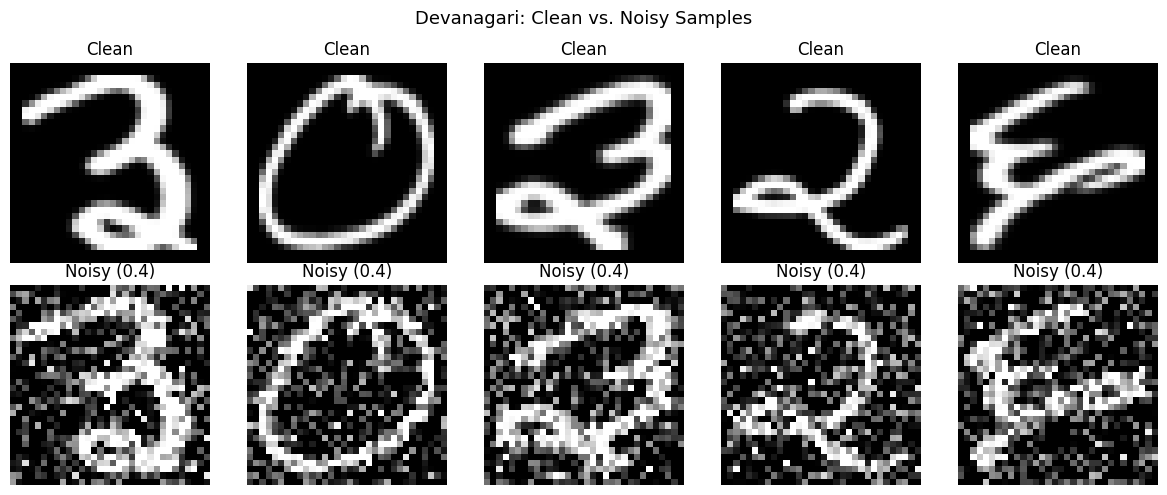

In [18]:
# ── Add Gaussian noise (factor = 0.4) ────────────────────────────────────────
NOISE = 0.4

X_dev_train_noisy = np.clip(X_dev_train + NOISE * np.random.normal(0., 1., X_dev_train.shape), 0., 1.)
X_dev_val_noisy   = np.clip(X_dev_val   + NOISE * np.random.normal(0., 1., X_dev_val.shape),   0., 1.)

# ── Quick visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_dev_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[0, i].set_title("Clean");  axes[0, i].axis('off')
    axes[1, i].imshow(X_dev_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[1, i].set_title(f"Noisy ({NOISE})"); axes[1, i].axis('off')
plt.suptitle("Devanagari: Clean vs. Noisy Samples", fontsize=13)
plt.tight_layout()
plt.show()

### Step 2 — Build the Deep Denoising Autoencoder (≥ 4 Encoder Layers)

In [19]:
def build_deep_encoder(input_shape=(32, 32, 1)):
    """
    Deep Encoder — 4 convolutional blocks.

    Spatial resolution path:
        32×32×1  → Conv(32)  → MaxPool → 16×16×32
                 → Conv(64)  → MaxPool →  8×8×64
                 → Conv(128) → MaxPool →  4×4×128
                 → Conv(256)            →  4×4×256  ← latent space

    Note: no pooling after the 4th conv to keep spatial size for reconstruction.
    """
    input_img = Input(shape=input_shape, name="input")

    # ── Block 1 ───────────────────────────────────────────────────────────────
    x = Conv2D(32,  (3, 3), activation='relu', padding='same', name="enc_conv1")(input_img)
    x = MaxPooling2D((2, 2), padding='same', name="enc_pool1")(x)   # → 16×16×32

    # ── Block 2 ───────────────────────────────────────────────────────────────
    x = Conv2D(64,  (3, 3), activation='relu', padding='same', name="enc_conv2")(x)
    x = MaxPooling2D((2, 2), padding='same', name="enc_pool2")(x)   # → 8×8×64

    # ── Block 3 ───────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name="enc_conv3")(x)
    x = MaxPooling2D((2, 2), padding='same', name="enc_pool3")(x)   # → 4×4×128

    # ── Block 4 — bottleneck (no further downsampling) ────────────────────────
    encoded = Conv2D(256, (3, 3), activation='relu', padding='same', name="latent")(x)  # 4×4×256

    return input_img, encoded


def build_deep_decoder(encoded_input):
    """
    Deep Decoder — mirrors the encoder with UpSampling.

    Path:
        4×4×256  → Conv(128) → UpSample →  8×8×128
                 → Conv(64)  → UpSample → 16×16×64
                 → Conv(32)  → UpSample → 32×32×32
                 → Conv(1, sigmoid)     → 32×32×1  ← reconstruction
    """
    # ── Block 1 ───────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name="dec_conv1")(encoded_input)
    x = UpSampling2D((2, 2), name="dec_up1")(x)   # → 8×8×128

    # ── Block 2 ───────────────────────────────────────────────────────────────
    x = Conv2D(64,  (3, 3), activation='relu', padding='same', name="dec_conv2")(x)
    x = UpSampling2D((2, 2), name="dec_up2")(x)   # → 16×16×64

    # ── Block 3 ───────────────────────────────────────────────────────────────
    x = Conv2D(32,  (3, 3), activation='relu', padding='same', name="dec_conv3")(x)
    x = UpSampling2D((2, 2), name="dec_up3")(x)   # → 32×32×32

    # ── Output layer — sigmoid keeps values in [0, 1] ─────────────────────────
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)  # 32×32×1

    return decoded


def build_deep_autoencoder(input_shape=(32, 32, 1)):
    """
    Assembles and compiles the full deep denoising convolutional autoencoder.
    """
    input_img, encoded_output = build_deep_encoder(input_shape)
    decoded_output = build_deep_decoder(encoded_output)
    model = Model(inputs=input_img, outputs=decoded_output, name="deep_autoencoder")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model


# ── Build & summarise ─────────────────────────────────────────────────────────
deep_ae = build_deep_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
deep_ae.summary()

Model: "deep_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Conv2D)                 │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3 (UpSampling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,425 (2.96 MB)

 Trainable params: 775,425 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

### Step 3 — Train the Deep Autoencoder

In [20]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────────────
history_dev = deep_ae.fit(
    X_dev_train_noisy, X_dev_train,    # INPUT: noisy  |  TARGET: clean
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(X_dev_val_noisy, X_dev_val),
    callbacks=[early_stop]
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.3600 - val_loss: 0.2452
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2049 - val_loss: 0.1844
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1763 - val_loss: 0.1693
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1663 - val_loss: 0.1621
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1598 - val_loss: 0.1580
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1553 - val_loss: 0.1548
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1522 - val_loss: 0.1523
Epoch 8/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1500 - val_loss: 0.1510
Epoch 9/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1476 - val_loss: 0.1493
Epoch 10/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1458 - val_loss: 0.1478
Epoch 11/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1445 - val_loss: 0.1478
Epoch 12/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/st

In [ ]:
# ── Loss Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(history_dev.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history_dev.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Devanagari Deep Autoencoder — Training Loss', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Step 4 — Evaluate and Visualise Results

In [ ]:
# ── Predict denoised images on validation set ─────────────────────────────────
denoised_dev = deep_ae.predict(X_dev_val_noisy[:10])

# ── Visualise: Noisy | Denoised | Clean ───────────────────────────────────────
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(20, 7))

row_labels = ["Noisy Input", "Denoised (AE)", "Clean Original"]
sources    = [X_dev_val_noisy[:n_show], denoised_dev, X_dev_val[:n_show]]

for row_idx, (label, imgs) in enumerate(zip(row_labels, sources)):
    for col_idx in range(n_show):
        axes[row_idx, col_idx].imshow(imgs[col_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(label, fontsize=11, rotation=0,
                                               labelpad=80, va='center')

plt.suptitle("Devanagari Deep Denoising Autoencoder — Final Output", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Step 5 — Experiment and Fine-Tune

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT: Compare reconstruction quality at different noise levels
# ══════════════════════════════════════════════════════════════════════════════

noise_levels   = [0.1, 0.3, 0.5, 0.7]
n_demo_samples = 4   # one row per sample

# Pick 4 clean validation images
sample_clean = X_dev_val[:n_demo_samples]

fig, axes = plt.subplots(
    n_demo_samples,
    len(noise_levels) + 2,   # clean | noise_0.1 denoised | noise_0.3 denoised | ...
    figsize=(16, 10)
)

col_titles = ["Clean"] + [f"Noise={n}" for n in noise_levels]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

for row in range(n_demo_samples):
    # Column 0: clean image
    axes[row, 0].imshow(sample_clean[row].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    axes[row, 0].axis('off')

    for col, nf in enumerate(noise_levels, start=1):
        noisy_img = np.clip(
            sample_clean[row:row+1] + nf * np.random.normal(0., 1., sample_clean[row:row+1].shape),
            0., 1.
        )
        denoised_img = deep_ae.predict(noisy_img, verbose=0)
        axes[row, col].imshow(denoised_img[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        axes[row, col].axis('off')

plt.suptitle("Effect of Noise Level on Denoising Quality", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# ── Quantitative comparison: MSE at each noise level ─────────────────────────
print(f"{'Noise Level':>14} | {'MSE (noisy vs clean)':>22} | {'MSE (denoised vs clean)':>25}")
print("-" * 68)

for nf in noise_levels:
    noisy   = np.clip(X_dev_val + nf * np.random.normal(0., 1., X_dev_val.shape), 0., 1.)
    denoised = deep_ae.predict(noisy, verbose=0)
    mse_noisy    = np.mean((noisy    - X_dev_val) ** 2)
    mse_denoised = np.mean((denoised - X_dev_val) ** 2)
    print(f"{nf:>14.1f} | {mse_noisy:>22.5f} | {mse_denoised:>25.5f}")

   Noise Level |   MSE (noisy vs clean) |   MSE (denoised vs clean)
--------------------------------------------------------------------
           0.1 |                0.00581 |                   0.01006
           0.3 |                0.04795 |                   0.01003
           0.5 |                0.11610 |                   0.01414
           0.7 |                0.17958 |                   0.02615
